# BB84 Quantum Key Distribution - With Attacker

This notebook implements BB84 in the presence of an attacker, Eve. The aim is to show that an intercept-resend attack disturbs the transmitted qubits and can therefore be detected by Alice and Bob through public error checking.

In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [2]:
# Setup
simulator = BasicSimulator()

# Number of qubits Alice sends
N = 50

# If error rate exceeds this, they abort
ERROR_THRESHOLD  = 0.15

print(f"N={N} qubits, error threshold={ERROR_THRESHOLD}")

N=50 qubits, error threshold=0.15


## Choice of Number of Qubits and Detection Threshold

A larger value of `N` is used here than in the no-attacker case because attack detection is statistical. After basis sifting, only about half of the transmitted qubits remain, and some of those must then be sacrificed for checking. The error threshold is chosen below the expected intercept-resend disturbance rate so that Eve is likely to be detected.

## Quantum Random Number Generation

The assignment requires the random choices in BB84 to be generated from quantum measurement rather than from a classical pseudo-random number generator. For this reason, random bits are produced by preparing the state $|+\rangle$ and measuring it, which gives `0` or `1` with equal probability.

In [3]:
def quantum_random_bit():
  """
  Generate one truly random bit by preparing |+⟩ = (|0⟩+|1⟩)/√2
  and measuring it.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

def quantum_random_bits(n):
  """Generate n random bits by calling quantum_random_bit() n times."""
  return [quantum_random_bit() for _ in range(n)]

# Quick sanity check
sample = quantum_random_bits(10)
print("Sample quantum random bits:", sample)

Sample quantum random bits: [1, 0, 0, 1, 1, 1, 1, 0, 0, 0]


## Alice

Alice generates random data bits and random basis choices, then encodes each bit into a qubit using the standard or diagonal basis. These qubits are sent into the quantum channel, where Eve may interfere with them before they reach Bob.

In [4]:
alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def encoding_circuit(bit, basis):
    """Return Alice's 1-qubit encoding circuit without measurement."""
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

def alice_prepare_qubit(bit, basis):
    """
    Prepare a qubit encoding `bit` in `basis`.

    Standard (basis=0):  0 -> |0> (no gate)   1 -> |1> (X gate)
    Diagonal (basis=1):  0 -> |+> (H gate)    1 -> |-> (X then H)
    """
    qc = QuantumCircuit(1, 1)
    qc.compose(encoding_circuit(bit, basis), inplace=True)
    return qc

# Alice sends qubits into the quantum channel (where Eve is waiting)
alice_channel = [alice_prepare_qubit(alice_bits[i], alice_bases[i]) for i in range(N)]

print("=== ALICE ===")
print(f"Bits:  {alice_bits[:20]} ... (showing first 20)")
print(f"Bases: {['S' if b==0 else 'D' for b in alice_bases[:20]]} ...")
print(f"\nAlice has prepared {N} qubits and sent them into the channel.")

=== ALICE ===
Bits:  [0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0] ... (showing first 20)
Bases: ['S', 'D', 'D', 'S', 'D', 'S', 'D', 'D', 'D', 'D', 'D', 'D', 'S', 'D', 'S', 'D', 'D', 'S', 'S', 'S'] ...

Alice has prepared 50 qubits and sent them into the channel.


## Alice Circuit Example

A single example qubit is shown below to make Alice's encoding step explicit in circuit, state, and operator form.

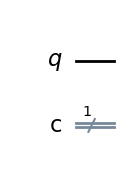

In [5]:
# Show Alice's first prepared qubit as a circuit diagram.
inspection_index = 0
alice_example = alice_channel[inspection_index]
alice_example.draw("mpl")

In [6]:
# Calculate the state from |0> and display it symbolically.
# Uses the measurement-free version of Alice's same bit and basis.
alice_unitary_example = encoding_circuit(alice_bits[inspection_index], alice_bases[inspection_index])
state = Statevector.from_int(0, 2)
state = state.evolve(alice_unitary_example)
state.draw("latex")

<IPython.core.display.Latex object>

In [7]:
U = Operator(alice_unitary_example)
array_to_latex(U)

<IPython.core.display.Latex object>

## Eve: Intercept-Resend Attack

Eve measures each transmitted qubit in a randomly chosen basis and then resends a fresh qubit based on her measurement result. If Eve chooses the wrong basis, she disturbs the original state, which creates errors that can later be detected by Alice and Bob.

In [8]:
eve_bases = quantum_random_bits(N)

def eve_intercept_and_resend(qubit_circuit, eve_basis):
    """
    Eve intercepts `qubit_circuit`, measures it in `eve_basis`,
    and returns a freshly prepared qubit matching her measurement result.

    This simulates the No-Cloning constraint: Eve cannot copy the unknown
    qubit, so she must measure it and then resend a new qubit to Bob.
    """
    # Eve Measure
    qc = qubit_circuit.copy()
    if eve_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    eve_bit = int(list(result.get_counts().keys())[0])

    # Resends a fresh qubit matching her measurement
    new_qc = QuantumCircuit(1, 1)
    if eve_bit == 1:
        new_qc.x(0)
    if eve_basis == 1:
        new_qc.h(0)
    return new_qc

# Eve sits on the channel and tampers with all N qubits
eve_channel = [eve_intercept_and_resend(alice_channel[i], eve_bases[i]) for i in range(N)]

print("=== EVE ===")
print(f"Bases: {['S' if b==0 else 'D' for b in eve_bases[:20]]} ...")
print(f"\nEve has intercepted all {N} qubits, measured them, and resent fresh qubits to Bob.")

=== EVE ===
Bases: ['D', 'D', 'D', 'D', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'D', 'S', 'S', 'S', 'D', 'D'] ...

Eve has intercepted all 50 qubits, measured them, and resent fresh qubits to Bob.


## Eve Circuit Example

The following circuit examples separate Eve's measurement step from the fresh qubit she resends. This makes the disturbance caused by the intercept-resend attack easier to see.

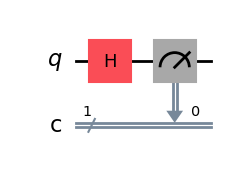

In [9]:
eve_measurement_example = alice_channel[inspection_index].copy()
if eve_bases[inspection_index] == 1:
    eve_measurement_example.h(0)
eve_measurement_example.measure(0, 0)
eve_measurement_example.draw("mpl")

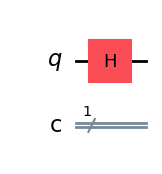

In [10]:
eve_resend_example = eve_channel[inspection_index]
eve_resend_example.draw("mpl")

## Bob

Bob receives the qubits after Eve's interference and measures them in his own random bases. Even when Bob later finds that his basis matched Alice's, Eve's earlier measurement may already have changed the state and introduced an error.

In [11]:
bob_bases = quantum_random_bits(N)

def bob_measure_qubit(qubit_circuit, basis):
    """Bob measures the received qubit in his chosen basis."""
    qc = qubit_circuit.copy()
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=1).result()
    return int(list(result.get_counts().keys())[0])

# Bob measures from Eve's tampered channel (he thinks it's Alice's)
bob_bits = [bob_measure_qubit(eve_channel[i], bob_bases[i]) for i in range(N)]

print("=== BOB ===")
print(f"Bases: {['S' if b==0 else 'D' for b in bob_bases[:20]]} ...")
print(f"Bits:  {bob_bits[:20]} ...")

=== BOB ===
Bases: ['S', 'S', 'D', 'D', 'S', 'S', 'D', 'S', 'D', 'S', 'S', 'S', 'S', 'S', 'S', 'D', 'S', 'D', 'D', 'D'] ...
Bits:  [1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0] ...


## Bob Circuit Example

A single measurement example is shown below to illustrate Bob's basis choice and final measurement step.

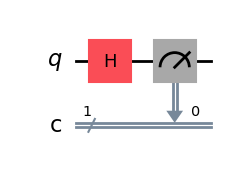

In [12]:
bob_measurement_example = eve_channel[inspection_index].copy()
if bob_bases[inspection_index] == 1:
    bob_measurement_example.h(0)
bob_measurement_example.measure(0, 0)
bob_measurement_example.draw("mpl")

## Public Channel: Basis Comparison

Alice and Bob publicly compare their basis choices and retain only the positions where the bases match. These positions form the sifted key, which is then used for attack detection.

In [13]:
matching_indices = [i for i in range(N) if alice_bases[i] == bob_bases[i]]

alice_sifted = [alice_bits[i] for i in matching_indices]
bob_sifted   = [bob_bits[i]   for i in matching_indices]

print("=== PUBLIC CHANNEL: BASIS COMPARISON ===")
print(f"Total qubits    : {N}")
print(f"Basis matches   : {len(matching_indices)}")
print(f"Sifted key len  : {len(alice_sifted)} bits")

=== PUBLIC CHANNEL: BASIS COMPARISON ===
Total qubits    : 50
Basis matches   : 23
Sifted key len  : 23 bits


## Attack Detection

Alice and Bob publicly reveal a random sample of the sifted bits and calculate the sample error rate. If this error rate exceeds the chosen threshold, they conclude that the channel has been disturbed and abort the protocol.

In this implementation, the sample is chosen by a random binary mask generated from quantum measurement, so each sifted bit is independently selected for checking with probability $\frac{1}{2}$. This gives an expected sample size of about half of the sifted key, which is large enough for a meaningful error estimate while still leaving unrevealed bits available.



In [14]:
n_sifted = len(alice_sifted)

# Use quantum randomness to decide which sifted bits to sacrifice for checking.
mask = quantum_random_bits(n_sifted)
sample_indices = [i for i, m in enumerate(mask) if m == 1]
# If the random mask selects no check bits, sacrifice one sifted bit so the attack-detection sample is not empty.
if n_sifted > 0 and not sample_indices:
    sample_indices = [0]

sample_index_set = set(sample_indices)
key_indices = [i for i in range(n_sifted) if i not in sample_index_set]

# Compare sample bits over public channel
alice_sample = [alice_sifted[i] for i in sample_indices]
bob_sample   = [bob_sifted[i]   for i in sample_indices]

n_sample     = len(alice_sample)
errors       = sum(a != b for a, b in zip(alice_sample, bob_sample))
error_rate   = errors / n_sample if n_sample > 0 else 0

print("=== ATTACK DETECTION ===")
print(f"Sample size     : {n_sample} bits")
print(f"Errors found    : {errors}")
print(f"Error rate      : {error_rate:.1%}")
print(f"Threshold       : {ERROR_THRESHOLD:.1%}")
print()

attack_detected = error_rate > ERROR_THRESHOLD

if attack_detected:
    print(f"ATTACK DETECTED! Error rate {error_rate:.1%} exceeds threshold {ERROR_THRESHOLD:.1%}.")
    print("   Alice and Bob ABORT - the channel is compromised.")
    print("   Eve's intercept-resend attack introduced errors because measurement disturbed some qubits.")
else:
    print(f"No attack detected. Error rate {error_rate:.1%} is within threshold.")
    print("   This can happen by chance if the sample is small; larger N improves confidence.")

=== ATTACK DETECTION ===
Sample size     : 13 bits
Errors found    : 3
Error rate      : 23.1%
Threshold       : 15.0%

ATTACK DETECTED! Error rate 23.1% exceeds threshold 15.0%.
   Alice and Bob ABORT - the channel is compromised.
   Eve's intercept-resend attack introduced errors because measurement disturbed some qubits.


## Remaining Key Analysis

The unrevealed sifted bits form the remaining candidate key. In this notebook, Alice's and Bob's remaining bits are compared only for simulation analysis, to show that Eve's disturbance can also affect unrevealed positions. In the actual BB84 protocol, these remaining key bits would not be publicly compared.

In [15]:
alice_key = [alice_sifted[i] for i in key_indices]
bob_key = [bob_sifted[i]   for i in key_indices]

key_errors    = sum(a != b for a, b in zip(alice_key, bob_key))
key_error_rate = key_errors / len(alice_key) if alice_key else 0

print("=== KEY COMPARISON (for analysis) ===")
print(f"Remaining key length : {len(alice_key)} bits")
print(f"Key errors           : {key_errors}  ({key_error_rate:.1%} error rate)")
print()
print("Alice's key:", alice_key[:30], "..." if len(alice_key) > 30 else "")
print("Bob's key:  ", bob_key[:30],   "..." if len(bob_key) > 30 else "")
print()
print(f"Note: the {key_error_rate:.1%} key error rate confirms Eve's intercept-resend attack was active.")
print("Alice and Bob should have aborted — their 'shared key' is corrupted.")

=== KEY COMPARISON (for analysis) ===
Remaining key length : 10 bits
Key errors           : 2  (20.0% error rate)

Alice's key: [0, 1, 0, 1, 1, 0, 0, 1, 0, 1] 
Bob's key:   [1, 1, 0, 1, 1, 0, 1, 1, 0, 1] 

Note: the 20.0% key error rate confirms Eve's intercept-resend attack was active.
Alice and Bob should have aborted — their 'shared key' is corrupted.


The sample error rate and the remaining key error rate may be different because they are calculated from different random subsets of the sifted bits. The sample bits are sacrificed for attack detection, while the remaining bits are the candidate key bits.

In a real BB84 protocol, Alice and Bob would not publicly compare the remaining key bits, because doing so would reveal the key. This comparison is included only for simulation analysis, where both Alice's and Bob's full bit lists are available.

## Measurement Histogram

The histogram below summarises Bob's measurement outcomes after Eve's interference. It is included as an outcome summary only and is separate from the sample-based attack-detection calculation.

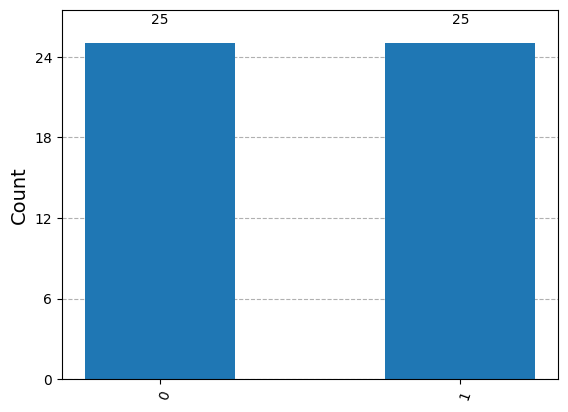

In [16]:
bob_measurement_counts = {
    "0": bob_bits.count(0),
    "1": bob_bits.count(1),
}
plot_histogram(bob_measurement_counts)

## Summary

The attacker simulation is successful if Eve introduces a noticeable sample error rate and the protocol reports that the channel should be aborted. The random-mask checking method is sufficient here because it uses quantum randomness consistently and, on average, checks about half of the sifted bits.

In [17]:
print("===== BB84 PROTOCOL SUMMARY (With Attacker) =====")
print(f"  Qubits sent by Alice         : {N}")
print(f"  Basis matches (sifted)       : {len(matching_indices)}")
print(f"  Sample bits checked          : {n_sample}")
print(f"  Sample error rate            : {error_rate:.1%}  (expected ~25% with Eve)")
print(f"  Attack detected              : {attack_detected}")
print(f"  Key error rate (if used)     : {key_error_rate:.1%}")
print()
print("Security guarantee: the No-Cloning Theorem ensures Eve cannot intercept qubits without disturbing them, making her presence detectable.")

===== BB84 PROTOCOL SUMMARY (With Attacker) =====
  Qubits sent by Alice         : 50
  Basis matches (sifted)       : 23
  Sample bits checked          : 13
  Sample error rate            : 23.1%  (expected ~25% with Eve)
  Attack detected              : True
  Key error rate (if used)     : 20.0%

Security guarantee: the No-Cloning Theorem ensures Eve cannot intercept qubits without disturbing them, making her presence detectable.
